In [61]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [62]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [63]:
len(words)

32033

In [64]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [65]:
block_size = 3
X , Y = [],[]
for w in words:
   # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context),'----->', itos[ix])
        context  = context [1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [66]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [198]:
def build_dataset(words):
    block_size = 3
    X , Y = [] , []
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w +'.':
          ix = stoi[ch]
          X.append(context)
          Y.append(ix)
            #print(''.join(itos[i] for i in context),'----->', itos[ix])
          context  = context [1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape , Y.shape)
    return X , Y
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr , Ytr = build_dataset(words[:n1])
Xdev , Ydev = build_dataset(words[n1:n2])
Xte , Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [67]:
C = torch.randn((27,2))


In [68]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [69]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [70]:
h  = torch.tanh(emb.view(-1 , 6) @ W1 + b1)


In [71]:
#torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1) == torch.cat(torch.unbind(emb , 1),1)

In [72]:
(emb.view(-1 , 6) @ W1 + b1).shape

torch.Size([228146, 100])

In [73]:
h.shape

torch.Size([228146, 100])

In [74]:
W2 = torch.randn((100,27))
b2 = torch.randn(27)

In [75]:
logits = h @ W2 + b2

In [76]:
logits.shape

torch.Size([228146, 27])

In [77]:
count = logits.exp()

In [78]:
prob = count / count.sum(1,keepdim = True)

In [79]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [80]:
#Better :


In [188]:
Xtr.shape,Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [115]:
emb = C[X]
h  = torch.tanh(emb.view(-1 , 6) @ W1 + b1)
logits = h @ W2 + b2
prob = count / count.sum(1,keepdim = True)
count = logits.exp()
F.cross_entropy(logits,Y)
loss

IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

In [116]:
logits = torch.tensor([100,-3,0,5])
count = logits.exp()
prob = count / count.sum()
prob


tensor([nan, 0., 0., 0.])

320.0635681152344


In [201]:
#Setting Up parameters:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2))
W1 = torch.randn((6,300))
b1 = torch.randn(300)
W2 = torch.randn((300,27))
b2 = torch.randn(27)
parameters = [C,W1,b1,W2,b2]

In [202]:
sum(p.nelement() for p in parameters)

10281

In [203]:
for p in parameters:
    p.requires_grad = True

In [204]:
lre  = torch.linspace(-3,0,1000)
lrs  = 10**lre


In [210]:
lri = []
lossi = []
stepi =[]

for i in range(30000):
    ix = torch.randint(0,Xtr.shape[0],(32,))    
    emb = C[Xtr[ix]]
    h  = torch.tanh(emb.view(-1 , 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Ytr[ix])
    #print(loss.item())       
    
    #backward_Pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    lr = 0.35
    for p in parameters:
        p.data += -lr*p.grad
    #Trackstats:
    #lri.append(lr)
    stepi.append(i)
    lossi.append(loss.item())
#print(loss.item())       


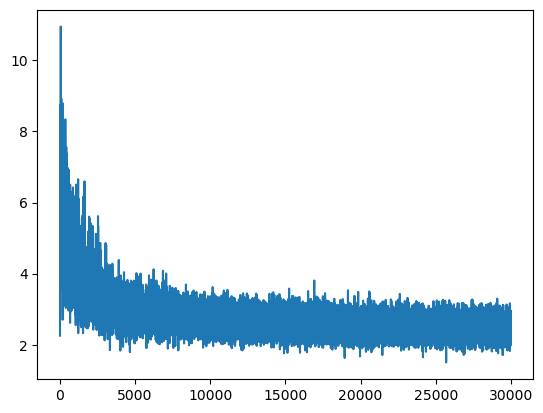

In [212]:
plt.plot(stepi,lossi)

In [213]:

print(loss.item())

2.4151785373687744


In [214]:
emb = C[Xtr]
h  = torch.tanh(emb.view(-1 , 6) @ W1 + b1)
logits = h @ W2 + b2
loss =F.cross_entropy(logits,Ytr)
loss

tensor(2.4143, grad_fn=<NllLossBackward0>)

In [215]:
emb = C[Xdev]
h  = torch.tanh(emb.view(-1 , 6) @ W1 + b1)
logits = h @ W2 + b2
loss =F.cross_entropy(logits,Ydev)
loss

tensor(2.4152, grad_fn=<NllLossBackward0>)